In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Step 1: Face Recognition

Detect the faces from the test images picture and stored them under stored-face folder

In [2]:
import cv2

alg = "haarcascade_frontalface_default.xml"
# Passing the cascade to opencv
haar_cascade = cv2.CascadeClassifier(alg)
#uploading the image
filename = "public/Spider-Man BND.png"
# Reading the image in grayscale
img = cv2.imread(filename, 0)

''' 
Suppose you want to read the image in color, you can use the following code instead:
Create a black and white version of the image
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
'''

# Detecting the faces in the image
faces = haar_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(100,100))

i = 0
for (x,y,w,h) in faces:
    
    cropped_img = img[y:y+h, x:x+w] #cropped_image = img[start_y : end_y, start_x : end_x]
    target_filename = f"public/stored-faces/cropped_face_{i}.png"
    cv2.imwrite(
        target_filename,
        cropped_img,
    )
    i += 1

## Embeddings Calculation

Calculate the embeddings from the faces and pushing to PostgreSQL, it needs to change the <SERVICE_URI> parameter with the PoostgreSQL Service URI

In [3]:
import os

import psycopg2
import torch
from dotenv import load_dotenv
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

load_dotenv()
password = os.getenv("POSTGRES_PASSWORD")

# Connect to Docker Postgres database
conn = psycopg2.connect(
    host="localhost",
    port=5433,
    database="face-recognition",
    user="postgres",
    password=password
)

# CLIP ViT-B/32. vision_model.pooler_output is 768-dim, which matches VECTOR(768).
# (model.get_image_features() would give the projected 512-dim vector instead.)
MODEL_NAME = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.eval()

folder = "public/stored-faces"
cur = conn.cursor()

for filename in sorted(os.listdir(folder)):
    if not filename.endswith(".png"):
        continue

    with Image.open(os.path.join(folder, filename)) as img:
        inputs = processor(images=img.convert("RGB"), return_tensors="pt")

    with torch.no_grad():
        embedding = model.vision_model(**inputs).pooler_output[0]

    cur.execute(
        "INSERT INTO pictures (picture, embedding) VALUES (%s, %s)",
        # pgvector parses its own text form: "[0.1, 0.2, ...]"
        (filename, str(embedding.tolist())),
    )

conn.commit()
cur.close()
conn.close()

#### CALCULATE EMBEDDINGS ON A NEW PICTURE

Closest match:  cropped_face_0.png


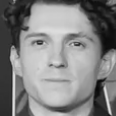

In [8]:
from IPython.display import display

conn = psycopg2.connect(
    host="localhost",
    port=5433,
    database="face-recognition",
    user="postgres",
    password=password
)


file_name = "public/tom.png" # filename of the added png

img = cv2.imread(file_name, 0)

faces = haar_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(100,100))

(x,y,w,h) = faces[0]

cropped_img =  img[y:y+h, x: x+w]

pil_img = Image.fromarray(cropped_img).convert("RGB")
inputs = processor(images=pil_img, return_tensors="pt")

with torch.no_grad():
    embedding = model.vision_model(**inputs).pooler_output[0]
    
curr = conn.cursor()
curr.execute(
    "SELECT picture FROM pictures ORDER BY embedding <-> %s LIMIT 1",
    (str(embedding.tolist()),)
)

result = curr.fetchone()
matched_filename = result[0]
print("Closest match: ", matched_filename)

matched_img = Image.open(os.path.join("public/stored-faces", matched_filename))
display(matched_img)

conn.close()